# Exploration des données — classification tumeur / pas tumeur

Ce notebook complète `getting_started.ipynb` : il sert à **comprendre le contenu** des fichiers `train.h5`, `val.h5`, `test.h5` (structure, volumes, centres, équilibre des classes) et à **visualiser** les patches pour guider les choix de prétraitement et de modèle sous **décalage de domaine entre hôpitaux**.

## 1. Configuration et imports

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional, List
from tqdm.auto import tqdm
from IPython.display import display

TRAIN_IMAGES_PATH = "train.h5"
VAL_IMAGES_PATH = "val.h5"
TEST_IMAGES_PATH = "test.h5"

SEED = 0
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["image.cmap"] = "gray"


def tensor_chw_to_display(im: np.ndarray) -> np.ndarray:
    """Convertit un tenseur (C, H, W) en une image affichable pour matplotlib."""
    if im.ndim == 2:
        return im.astype(np.float32)
    if im.ndim == 3 and im.shape[0] in (1, 3, 4):
        vis = np.moveaxis(im, 0, -1)
        if vis.shape[-1] == 1:
            return vis[..., 0].astype(np.float32)
        vis = vis[..., :3].astype(np.float32)
        vmax = float(vis.max()) if vis.max() > 1.0 else 1.0
        return np.clip(vis / vmax, 0, 1)
    return im.astype(np.float32)


## 2. Vérifier la présence des fichiers

Exécutez ce notebook depuis le répertoire qui contient les `.h5` (comme pour le baseline).

In [2]:
for p in [TRAIN_IMAGES_PATH, VAL_IMAGES_PATH, TEST_IMAGES_PATH]:
    path = Path(p)
    print(f"{p}: {'OK' if path.is_file() else 'MANQUANT'} ({path.resolve()})")

train.h5: MANQUANT (/Users/tiffneyaina/Kaggle-Challenge/train.h5)
val.h5: MANQUANT (/Users/tiffneyaina/Kaggle-Challenge/val.h5)
test.h5: MANQUANT (/Users/tiffneyaina/Kaggle-Challenge/test.h5)


## 3. Structure HDF5 (un exemple par fichier)

Hiérarchie attendue (cf. `getting_started.ipynb`) : pour chaque index `idx`, un groupe avec au minimum `img` ; souvent `label` (train/val) et `metadata` (premier élément = **centre**).

In [3]:
def describe_h5_file(path: str, name: str, n_keys_preview: int = 3) -> None:
    path = Path(path)
    if not path.is_file():
        print(f"[{name}] Fichier introuvable : {path}")
        return
    with h5py.File(path, "r") as f:
        keys = list(f.keys())
        print(f"\n=== {name} ({path}) ===")
        print(f"Nombre d'entrées (clés racine) : {len(keys):,}")
        if not keys:
            return
        sample_key = keys[0]
        g = f[sample_key]
        print(f"Exemple de clé : {sample_key!r}")
        print("Contenu du groupe :", list(g.keys()))
        for ds_name in g.keys():
            obj = g[ds_name]
            if isinstance(obj, h5py.Dataset):
                arr = np.array(obj)
                if ds_name == 'metadata':
                    # print un exemple de metadata
                    print(f"  - {ds_name}: {arr[0]}")
                else:
                    print(f"  - {ds_name}: shape={arr.shape}, dtype={arr.dtype}, min={np.min(arr)}, max={np.max(arr)}")
            else:
                print(f"  - {ds_name}: (groupe)")
        for k in keys[:n_keys_preview]:
            gg = f[k]
            if "img" not in gg:
                print(f"  [Attention] clé {k!r} sans dataset 'img'")


for p, label in [
    (TRAIN_IMAGES_PATH, "train"),
    (VAL_IMAGES_PATH, "val"),
    (TEST_IMAGES_PATH, "test"),
]:
    describe_h5_file(p, label)

[train] Fichier introuvable : train.h5
[val] Fichier introuvable : val.h5
[test] Fichier introuvable : test.h5


## 4. Table récapitulative : chaque patch

Parcours complet des clés (peut prendre quelques minutes si très gros volumes). Pour un **échantillon rapide**, définissez `MAX_KEYS` ci-dessous.

In [4]:
MAX_KEYS = None  # ex. 5000 pour un aperçu rapide ; None = tout parcourir


def build_manifest(h5_path: str, split_name: str, max_keys: Optional[int] = None) -> pd.DataFrame:
    rows = []
    with h5py.File(h5_path, "r") as f:
        keys = list(f.keys())
        if max_keys is not None:
            keys = keys[:max_keys]
        for k in tqdm(keys, desc=f"manifest {split_name}"):
            g = f[k]
            img = np.array(g["img"])
            row = {
                "split": split_name,
                "id": k,
                "c": img.shape[0] if img.ndim == 3 else None,
                "h": img.shape[1] if img.ndim >= 2 else None,
                "w": img.shape[2] if img.ndim == 3 else None,
                "shape_str": str(img.shape),
                "dtype": str(img.dtype),
            }
            if "label" in g:
                row["label"] = int(np.array(g["label"]).reshape(-1)[0])
            else:
                row["label"] = np.nan
            if "metadata" in g:
                meta = np.array(g["metadata"]).reshape(-1)
                row["center"] = int(meta[0]) if meta.size else np.nan
            else:
                row["center"] = np.nan
            rows.append(row)
    return pd.DataFrame(rows)


manifests = []
for path, split in [
    (TRAIN_IMAGES_PATH, "train"),
    (VAL_IMAGES_PATH, "val"),
    (TEST_IMAGES_PATH, "test"),
]:
    if Path(path).is_file():
        if split == 'train':
            manifests.append(build_manifest(path, split, MAX_KEYS))
        else:
            manifests.append(build_manifest(path, split, None))

if not manifests:
    raise FileNotFoundError("Aucun fichier .h5 trouvé. Placez train/val/test.h5 à côté du notebook.")

df = pd.concat(manifests, ignore_index=True)
df.head(10)

FileNotFoundError: Aucun fichier .h5 trouvé. Placez train/val/test.h5 à côté du notebook.

## 5. Synthèse quantitative

In [ ]:
print("Effectifs par split")
display(df.groupby("split").size().to_frame("n"))

print("\nFormes (C,H,W) distinctes par split")
display(df.groupby(["split", "shape_str"]).size().rename("n").reset_index().sort_values(["split", "n"], ascending=[True, False]))

labeled = df[~df["label"].isna()].copy()
if len(labeled):
    print("\nDistribution label (0/1) par split")
    display(
        labeled.groupby(["split", "label"]).size().rename("n").reset_index()
    )
    print("\nDistribution label par centre et split (train/val)")
    display(
        labeled.groupby(["split", "center", "label"]).size().rename("n").reset_index().sort_values(["split", "center", "label"])
    )

centers_by_split = df.groupby("split")["center"].agg(["nunique", "min", "max"])
print("\nCentres présents par split (nunique, min, max)")
display(centers_by_split)

print("\nEnsembles de centres (proxy domaine / hôpital)")
for split in ["train", "val", "test"]:
    s = df[df["split"] == split]["center"].dropna().unique()
    print(f"  {split}: {sorted(int(x) for x in s)}")
ctr = set(df[df["split"] == "train"]["center"].dropna().unique())
cva = set(df[df["split"] == "val"]["center"].dropna().unique())
cte = set(df[df["split"] == "test"]["center"].dropna().unique())
print("  val ⊆ train ?", cva <= ctr)
print("  test ⊆ train ?", cte <= ctr)

Effectifs par split


,n
split,
test,85054
train,100000
val,34904



Formes (C,H,W) distinctes par split


,split,shape_str,n
0,test,"(3, 96, 96)",85054
1,train,"(3, 96, 96)",100000
2,val,"(3, 96, 96)",34904



Distribution label (0/1) par split


...


Distribution label par centre et split (train/val)


,split,center,label,n
0,train,0.0,0.0,8815
1,train,0.0,1.0,8941
2,train,3.0,0.0,19293
3,train,3.0,1.0,19463
4,train,4.0,0.0,21672
5,train,4.0,1.0,21816
6,val,1.0,0.0,17452
7,val,1.0,1.0,17452



Centres présents par split (nunique, min, max)


,nunique,min,max
split,,,
test,0,NaN,NaN
train,3,0.0,4.0
val,1,1.0,1.0



Ensembles de centres (proxy domaine / hôpital)
  train: [0, 3, 4]
  val: [1]
  test: []
  val ⊆ train ? False
  test ⊆ train ? True


### Graphiques : équilibre des classes et répartition par centre

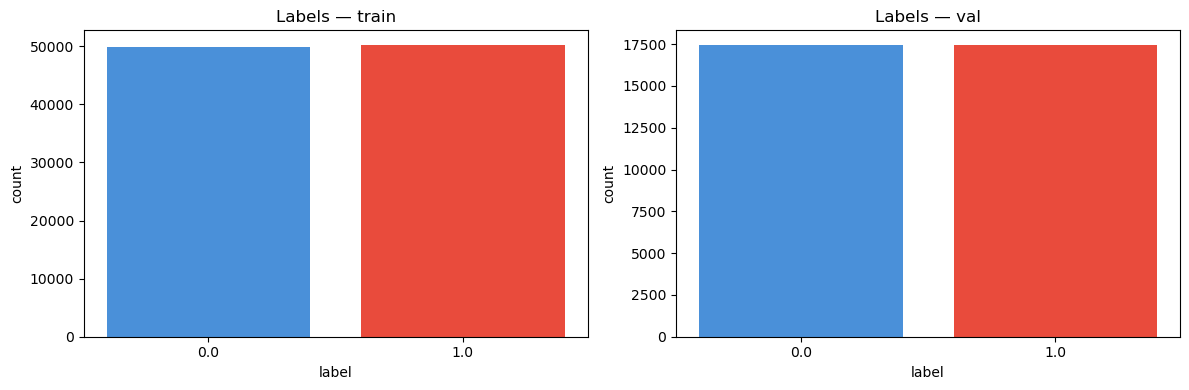

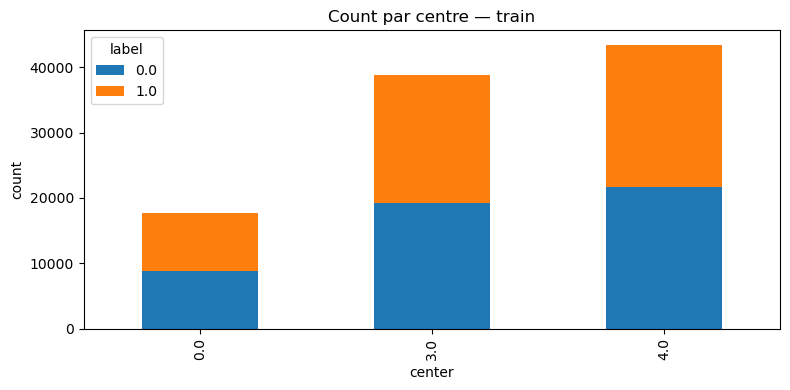

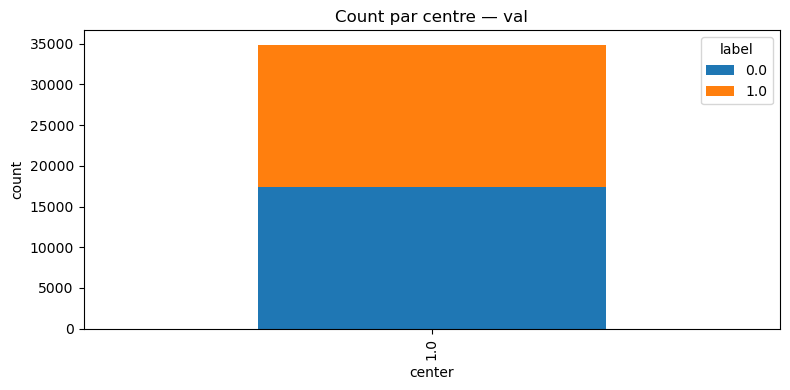

In [ ]:
labeled = df[~df["label"].isna()]
if len(labeled):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, split in zip(axes, ["train", "val"]):
        sub = labeled[labeled["split"] == split]
        if sub.empty:
            ax.set_visible(False)
            continue
        vc = sub["label"].value_counts().sort_index()
        ax.bar(vc.index.astype(str), vc.values, color=["#4a90d9", "#e94b3c"])
        ax.set_title(f"Labels — {split}")
        ax.set_xlabel("label")
        ax.set_ylabel("count")
    plt.tight_layout()
    plt.show()

    for split in ["train", "val"]:
        sub = labeled[labeled["split"] == split]
        if sub.empty:
            continue
        ct_s = sub.pivot_table(index="center", columns="label", values="id", aggfunc="count", fill_value=0)
        ct_s.plot(kind="bar", stacked=True, figsize=(8, 4), title=f"Count par centre — {split}")
        plt.xlabel("center")
        plt.ylabel("count")
        plt.legend(title="label")
        plt.tight_layout()
        plt.show()
else:
    print("Aucun label trouvé dans le manifest (vérifiez les fichiers .h5).")

## 6. Statistiques de pixels (sous-échantillon)

On estime la **moyenne** et l’**écart-type** par **canal de couleur** (chaque canal = une « couche » de l’image), pour chaque **centre / hôpital** quand cette info existe (`metadata`).

- **Train et validation** : une courbe par centre (couleurs différentes).
- **Test** : il n’y a souvent **pas** de `metadata` dans le fichier → on calcule une ligne pour **tout le test** d’un coup (comme si c’était un seul « gros centre »), pour quand même comparer train / val / test.

Les graphiques en barres montrent les **moyennes** ; une deuxième série montre les **écarts-types**. Si les barres diffèrent beaucoup d’un centre à l’autre, c’est le signe que les images ne « ressemblent pas » numériquement — d’où l’intérêt du prétraitement (section 9).

Les sections **6.1 à 6.5** en dessous vont plus loin (histogrammes, corrélations, effet d’une normalisation simple, images extrêmes, comparaison val vs train).


pixels:   0%|          | 0/96 [00:00<?, ?it/s]

pixels:   0%|          | 0/96 [00:00<?, ?it/s]

pixels:   0%|          | 0/96 [00:00<?, ?it/s]

pixels:   0%|          | 0/96 [00:00<?, ?it/s]

pixels:   0%|          | 0/256 [00:00<?, ?it/s]

,split,center,center_label,n_patches_used,mean,std
0,train,0.0,train c0,96,"[0.7161461844764374, 0.58293767735638, 0.68525...","[0.18464117295137544, 0.21791859720621778, 0.1..."
1,train,3.0,train c3,96,"[0.6791970587025086, 0.4867075794997315, 0.616...","[0.21010180713662777, 0.22816644576606446, 0.1..."
2,train,4.0,train c4,96,"[0.8085972037580278, 0.6880102631532483, 0.827...","[0.12525438677067655, 0.15027722612540984, 0.1..."
3,val,1.0,val c1,96,"[0.602243523630831, 0.46154745590562624, 0.590...","[0.19405778054831396, 0.2246948148774849, 0.18..."
4,test,NaN,test (tout le jeu),256,"[0.669509718408032, 0.48103786429985324, 0.737...","[0.21118775213924637, 0.23701321429060696, 0.1..."


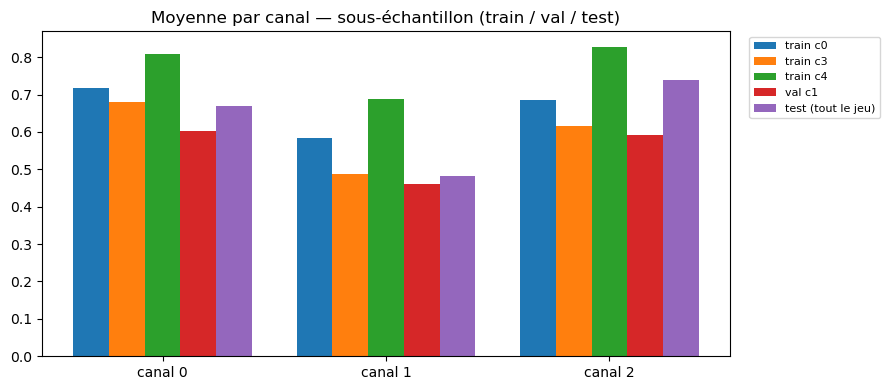

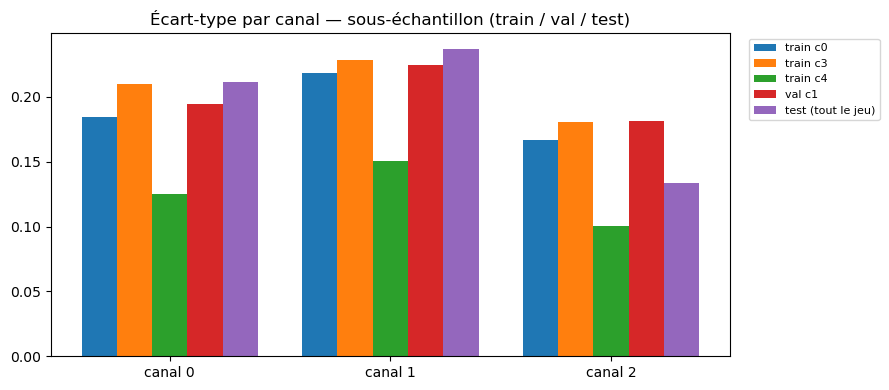

In [ ]:
STATS_SAMPLE_PER_CELL = 96  # patches échantillonnés par (split, centre) ; augmentez pour plus de stabilité
STATS_TEST_MAX_PATCHES = 256  # pour le test sans centre : un peu plus de patches pour compenser l’absence de découpage


def channel_mean_std(h5_path: str, id_list: List[str]) -> tuple:
    sums = None
    sumsq = None
    count = 0
    with h5py.File(h5_path, "r") as f:
        for k in tqdm(id_list, desc="pixels", leave=False):
            img = np.array(f[k]["img"]).astype(np.float64)
            if img.ndim != 3:
                continue
            flat = img.reshape(img.shape[0], -1)
            if sums is None:
                sums = flat.sum(axis=1)
                sumsq = (flat ** 2).sum(axis=1)
            else:
                sums = sums + flat.sum(axis=1)
                sumsq = sumsq + (flat ** 2).sum(axis=1)
            count += flat.shape[1]
    if count == 0 or sums is None:
        return np.array([]), np.array([])
    mean = sums / count
    var = sumsq / count - mean ** 2
    std = np.sqrt(np.maximum(var, 0))
    return mean, std


def center_group_label(split_name: str, center) -> str:
    if pd.isna(center):
        return f"{split_name} (tout le jeu)"
    return f"{split_name} c{int(center)}"


stats_rows = []
for split_name, path in [("train", TRAIN_IMAGES_PATH), ("val", VAL_IMAGES_PATH), ("test", TEST_IMAGES_PATH)]:
    if not Path(path).is_file():
        continue
    sub_df = df[df["split"] == split_name]
    centers = sorted(sub_df["center"].dropna().unique())

    if len(centers) == 0:
        ids = sub_df["id"].tolist()
        rng.shuffle(ids)
        ids = ids[: min(STATS_TEST_MAX_PATCHES, len(ids))]
        if not ids:
            continue
        m, s = channel_mean_std(path, ids)
        if m.size:
            stats_rows.append(
                {
                    "split": split_name,
                    "center": np.nan,
                    "center_label": center_group_label(split_name, np.nan),
                    "mean": m.tolist(),
                    "std": s.tolist(),
                    "n_patches_used": len(ids),
                }
            )
        continue

    for center in centers:
        cell = sub_df[sub_df["center"] == center]
        ids = cell["id"].tolist()
        rng.shuffle(ids)
        ids = ids[:STATS_SAMPLE_PER_CELL]
        if not ids:
            continue
        m, s = channel_mean_std(path, ids)
        if m.size:
            stats_rows.append(
                {
                    "split": split_name,
                    "center": float(center),
                    "center_label": center_group_label(split_name, center),
                    "mean": m.tolist(),
                    "std": s.tolist(),
                    "n_patches_used": len(ids),
                }
            )

if stats_rows:
    stats_df = pd.DataFrame(stats_rows)
    display(stats_df[["split", "center", "center_label", "n_patches_used", "mean", "std"]])

    nchan = len(stats_df.iloc[0]["mean"])
    if nchan:
        for stat_name, col in [("Moyenne", "mean"), ("Écart-type", "std")]:
            fig, ax = plt.subplots(figsize=(9, 4))
            splits = list(stats_df["split"].unique())
            bar_w = 0.8 / max(len(stats_df), 1)
            offsets = np.linspace(-0.4 + bar_w / 2, 0.4 - bar_w / 2, len(stats_df))
            x0 = np.arange(nchan)
            for off, (_, row) in zip(offsets, stats_df.iterrows()):
                vals = row[col]
                ax.bar(x0 + off, vals, bar_w, label=row["center_label"])
            ax.set_xticks(x0)
            ax.set_xticklabels([f"canal {j}" for j in range(nchan)])
            ax.set_title(f"{stat_name} par canal — sous-échantillon (train / val / test)")
            ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
            plt.tight_layout()
            plt.show()
else:
    print("Pas de stats calculées (fichiers manquants ou DataFrame vide).")


### 6.1 Histogrammes des intensités par canal

Pour chaque **canal** (R, G, B ou équivalent), on trace la **distribution** des valeurs de pixels (sous-échantillon). Des courbes décalées entre centres = mêmes « formes » d’image mais **histogrammes différents** → le modèle peut s’appuyer sur des artéfacts de couleur plutôt que sur la biologie. 


hist:   0%|          | 0/36 [00:00<?, ?it/s]

hist:   0%|          | 0/36 [00:00<?, ?it/s]

hist:   0%|          | 0/36 [00:00<?, ?it/s]

hist:   0%|          | 0/36 [00:00<?, ?it/s]

hist:   0%|          | 0/256 [00:00<?, ?it/s]

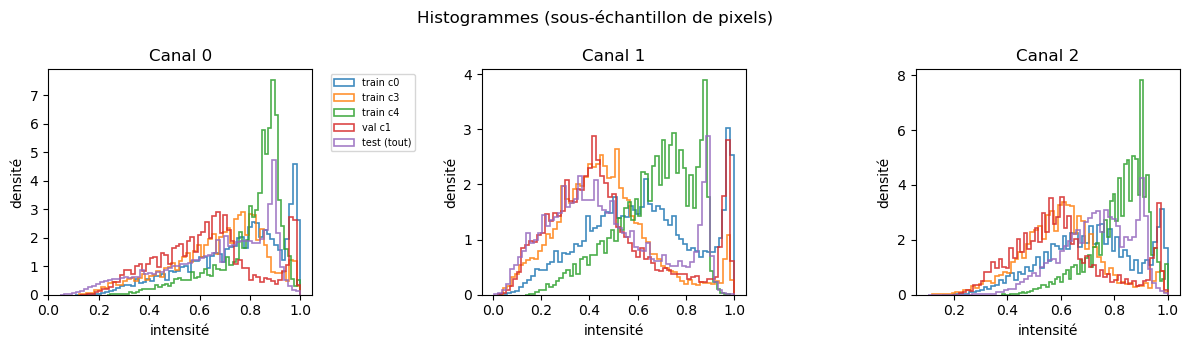

In [ ]:
HIST_PATCHES_PER_GROUP = 36
HIST_PIX_PER_PATCH = 600


def sample_ids_for_group(sub_df: pd.DataFrame) -> List[str]:
    if sub_df.empty:
        return []
    ids = sub_df["id"].tolist()
    rng.shuffle(ids)
    centers = sub_df["center"].dropna().unique()
    if len(centers) == 0:
        return ids[: min(STATS_TEST_MAX_PATCHES, len(ids))]
    return ids[:HIST_PATCHES_PER_GROUP]


def pooled_channel_samples(h5_path: str, id_list: List[str]) -> dict:
    """Regroupe des pixels par indice de canal."""
    chans = None
    vals = None
    with h5py.File(h5_path, "r") as f:
        for k in tqdm(id_list, desc="hist", leave=False):
            img = np.array(f[k]["img"]).astype(np.float64)
            if img.ndim != 3:
                continue
            c = img.shape[0]
            flat = img.reshape(c, -1)
            take = min(HIST_PIX_PER_PATCH, flat.shape[1])
            idx = rng.choice(flat.shape[1], size=take, replace=False)
            if chans is None:
                chans = c
                vals = [flat[ci, idx].tolist() for ci in range(c)]
            else:
                for ci in range(c):
                    vals[ci].extend(flat[ci, idx].tolist())
    if vals is None:
        return {}
    return {i: np.array(v, dtype=np.float64) for i, v in enumerate(vals)}


rows_hist = []
for split_name, path in [("train", TRAIN_IMAGES_PATH), ("val", VAL_IMAGES_PATH), ("test", TEST_IMAGES_PATH)]:
    if not Path(path).is_file():
        continue
    sub_all = df[df["split"] == split_name]
    centers = sorted(sub_all["center"].dropna().unique())
    if len(centers) == 0:
        ids = sample_ids_for_group(sub_all)
        lab = f"{split_name} (tout)"
        samp = pooled_channel_samples(path, ids)
        rows_hist.append((lab, samp))
        continue
    for center in centers:
        sub = sub_all[sub_all["center"] == center]
        ids = sample_ids_for_group(sub)
        lab = f"{split_name} c{int(center)}"
        samp = pooled_channel_samples(path, ids)
        rows_hist.append((lab, samp))

if rows_hist:
    nchan = max(len(h[1]) for h in rows_hist)
    fig, axs = plt.subplots(1, nchan, figsize=(4 * nchan, 3.5))
    if nchan == 1:
        axs = [axs]
    for ci in range(nchan):
        ax = axs[ci]
        for lab, samp in rows_hist:
            if ci not in samp or samp[ci].size == 0:
                continue
            x = samp[ci]
            x = x[np.isfinite(x)]
            if x.size == 0:
                continue
            ax.hist(x, bins=60, density=True, histtype="step", linewidth=1.2, label=lab, alpha=0.85)
        ax.set_title(f"Canal {ci}")
        ax.set_xlabel("intensité")
        ax.set_ylabel("densité")
    axs[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
    plt.suptitle("Histogrammes (sous-échantillon de pixels)")
    plt.tight_layout()
    plt.show()
else:
    print("Pas d'histogrammes (jeux manquants).")


### 6.2 Corrélation entre les canaux (par patch, puis moyenne)

Pour chaque patch on calcule à quel point les canaux **varient ensemble** (corrélation de Pearson sur les pixels). Puis on **moyenne** sur les patches d’un même groupe (split + centre).  
Si les **matrices** diffèrent beaucoup entre centres, les relations couleur ne sont pas les mêmes — encore un argument pour ne pas se fier qu’à la couleur « brute ».


corr train c0:   0%|          | 0/1000 [00:00<?, ?it/s]

corr train c3:   0%|          | 0/1000 [00:00<?, ?it/s]

corr train c4:   0%|          | 0/1000 [00:00<?, ?it/s]

corr val c1:   0%|          | 0/1000 [00:00<?, ?it/s]

corr test tout:   0%|          | 0/1000 [00:00<?, ?it/s]

/var/folders/t0/gw753q351rbc1y6tksb52wm00000gn/T/ipykernel_80122/4281820364.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


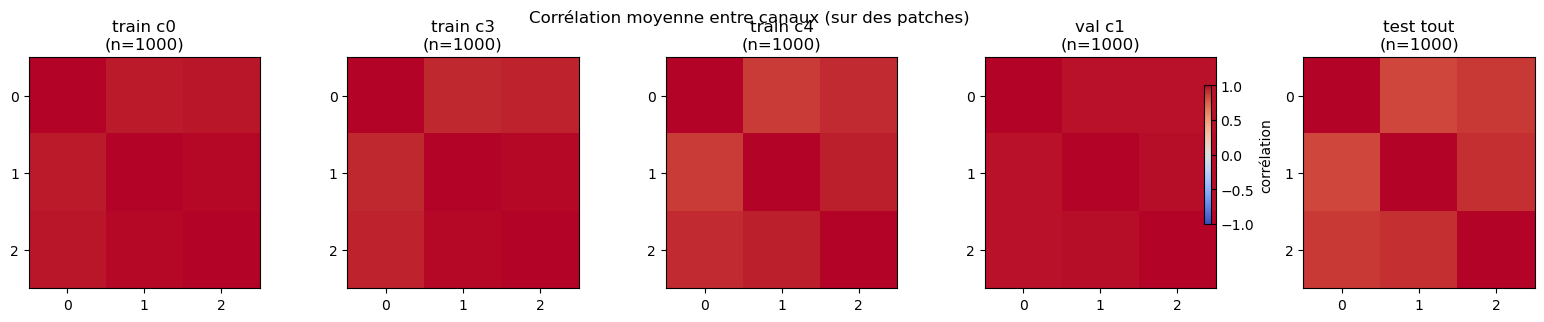

In [ ]:
CORR_PATCHES_PER_GROUP = 1000


def patch_correlation_matrix(img: np.ndarray) -> np.ndarray:
    x = img.astype(np.float64).reshape(img.shape[0], -1)
    if x.shape[1] < 2:
        return np.nan * np.ones((img.shape[0], img.shape[0]))
    return np.corrcoef(x)


corr_rows = []
for split_name, path in [("train", TRAIN_IMAGES_PATH), ("val", VAL_IMAGES_PATH), ("test", TEST_IMAGES_PATH)]:
    if not Path(path).is_file():
        continue
    sub_all = df[df["split"] == split_name]
    centers = sorted(sub_all["center"].dropna().unique())

    def accum(ids, label):
        mats = []
        with h5py.File(path, "r") as f:
            for k in tqdm(ids, desc=f"corr {label}", leave=False):
                m = patch_correlation_matrix(np.array(f[k]["img"]))
                if np.all(np.isfinite(m)):
                    mats.append(m)
        if not mats:
            return
        mean_m = np.mean(np.stack(mats, axis=0), axis=0)
        corr_rows.append({"group": label, "matrix": mean_m, "n": len(mats)})

    if len(centers) == 0:
        ids = sub_all["id"].tolist()
        rng.shuffle(ids)
        accum(ids[:CORR_PATCHES_PER_GROUP], f"{split_name} tout")
        continue
    for center in centers:
        sub = sub_all[sub_all["center"] == center]
        ids = sub["id"].tolist()
        rng.shuffle(ids)
        accum(ids[:CORR_PATCHES_PER_GROUP], f"{split_name} c{int(center)}")

if corr_rows:
    n_g = len(corr_rows)
    fig, axs = plt.subplots(1, n_g, figsize=(3.2 * n_g, 3))
    if n_g == 1:
        axs = [axs]
    vmax = 1.0
    vmin = -1.0
    for ax, row in zip(axs, corr_rows):
        im = ax.imshow(row["matrix"], vmin=vmin, vmax=vmax, cmap="coolwarm")
        ax.set_title(f'{row["group"]}\n(n={row["n"]})')
        ax.set_xticks(range(row["matrix"].shape[0]))
        ax.set_yticks(range(row["matrix"].shape[0]))
    fig.colorbar(im, ax=np.ravel(axs).tolist(), shrink=0.6, label="corrélation")
    plt.suptitle("Corrélation moyenne entre canaux (sur des patches)")
    plt.tight_layout()
    plt.show()
else:
    print("Pas de corrélations.")


### 6.3 Effet d’une normalisation « z-score par patch » (aperçu)

Pour chaque patch : sur chaque canal, on enlève la **moyenne** du canal et on divise par l’**écart-type** du canal (**sur ce patch seulement**).  
Ensuite on recalcule les **moyennes globales** (sur un sous-échantillon) comme en section 6 : si le prétraitement aide à **rapprocher** les centres, les barres devraient être plus alignées qu’avant.


zscore-pixels:   0%|          | 0/96 [00:00<?, ?it/s]

zscore-pixels:   0%|          | 0/96 [00:00<?, ?it/s]

zscore-pixels:   0%|          | 0/96 [00:00<?, ?it/s]

zscore-pixels:   0%|          | 0/96 [00:00<?, ?it/s]

zscore-pixels:   0%|          | 0/256 [00:00<?, ?it/s]

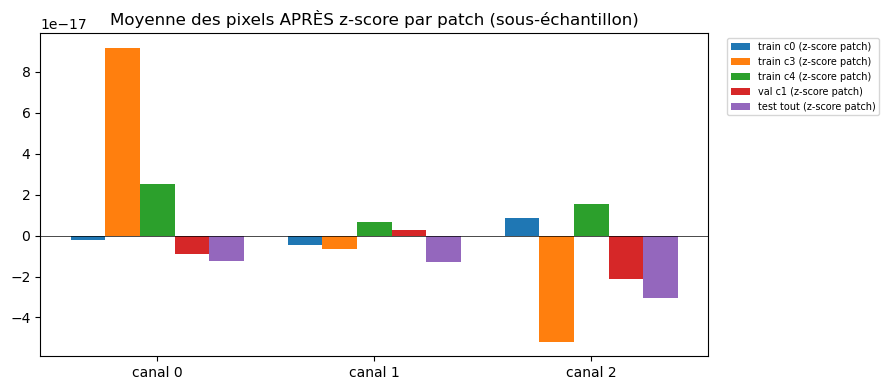

In [ ]:
def per_patch_zscore(img: np.ndarray) -> np.ndarray:
    x = img.astype(np.float64)
    out = np.zeros_like(x)
    for c in range(x.shape[0]):
        m = float(x[c].mean())
        s = float(x[c].std()) + 1e-6
        out[c] = (x[c] - m) / s
    return out


def channel_mean_std_from_processed(h5_path: str, id_list: List[str], transform) -> tuple:
    sums = None
    sumsq = None
    count = 0
    with h5py.File(h5_path, "r") as f:
        for k in tqdm(id_list, desc="zscore-pixels", leave=False):
            img = transform(np.array(f[k]["img"]))
            if img.ndim != 3:
                continue
            flat = img.reshape(img.shape[0], -1)
            if sums is None:
                sums = flat.sum(axis=1)
                sumsq = (flat ** 2).sum(axis=1)
            else:
                sums = sums + flat.sum(axis=1)
                sumsq = sumsq + (flat ** 2).sum(axis=1)
            count += flat.shape[1]
    if count == 0 or sums is None:
        return np.array([]), np.array([])
    mean = sums / count
    var = sumsq / count - mean ** 2
    std = np.sqrt(np.maximum(var, 0))
    return mean, std


z_rows = []
for split_name, path in [("train", TRAIN_IMAGES_PATH), ("val", VAL_IMAGES_PATH), ("test", TEST_IMAGES_PATH)]:
    if not Path(path).is_file():
        continue
    sub_all = df[df["split"] == split_name]
    centers = sorted(sub_all["center"].dropna().unique())

    def one_group(ids, label):
        if not ids:
            return
        m, s = channel_mean_std_from_processed(path, ids, per_patch_zscore)
        if m.size:
            z_rows.append({"group": label, "mean": m, "std": s})

    if len(centers) == 0:
        ids = sub_all["id"].tolist()
        rng.shuffle(ids)
        one_group(ids[:STATS_TEST_MAX_PATCHES], f"{split_name} tout (z-score patch)")
        continue
    for center in centers:
        sub = sub_all[sub_all["center"] == center]
        ids = sub["id"].tolist()
        rng.shuffle(ids)
        one_group(ids[:STATS_SAMPLE_PER_CELL], f"{split_name} c{int(center)} (z-score patch)")

if z_rows:
    nchan = len(z_rows[0]["mean"])
    fig, ax = plt.subplots(figsize=(9, 4))
    x0 = np.arange(nchan)
    width = 0.8 / len(z_rows)
    for i, row in enumerate(z_rows):
        ax.bar(x0 + (i - len(z_rows) / 2) * width + width / 2, row["mean"], width, label=row["group"])
    ax.axhline(0.0, color="k", linewidth=0.5)
    ax.set_xticks(x0)
    ax.set_xticklabels([f"canal {j}" for j in range(nchan)])
    ax.set_title("Moyenne des pixels APRÈS z-score par patch (sous-échantillon)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    print("Pas de comparaison z-score.")


### 6.4 Patches les plus clairs et les plus sombres (luminosité moyenne)

La **luminosité moyenne** = moyenne de tous les pixels de l’image (tous canaux).  
On trie les patches et on affiche les **3 plus clairs** et les **3 plus sombres** par groupe — pour repérer des outliers ou des différences d’acquisition.


L centre 0:   0%|          | 0/10000 [00:00<?, ?it/s]

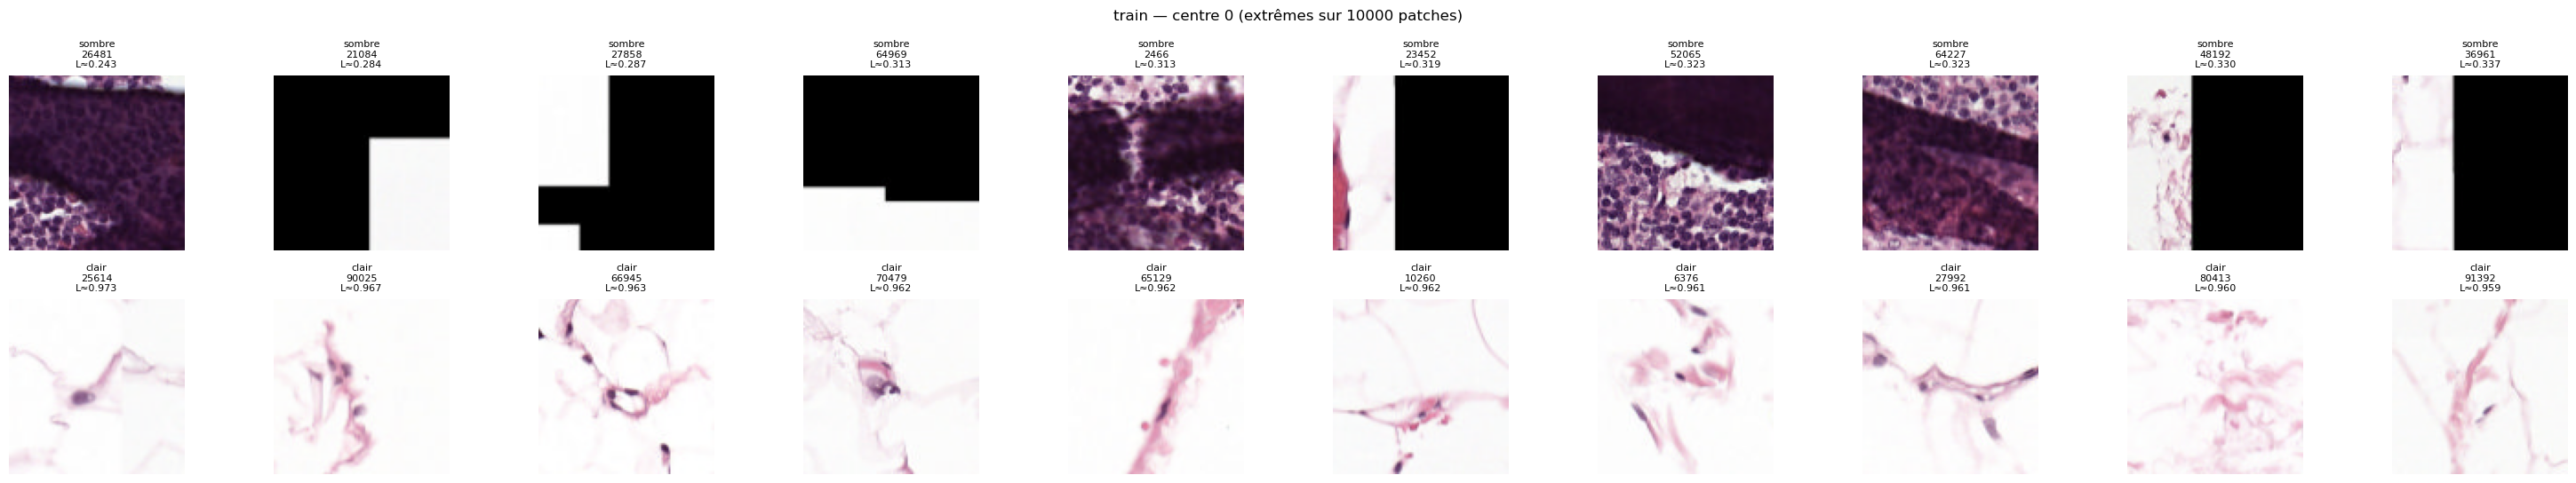

L centre 3:   0%|          | 0/10000 [00:00<?, ?it/s]

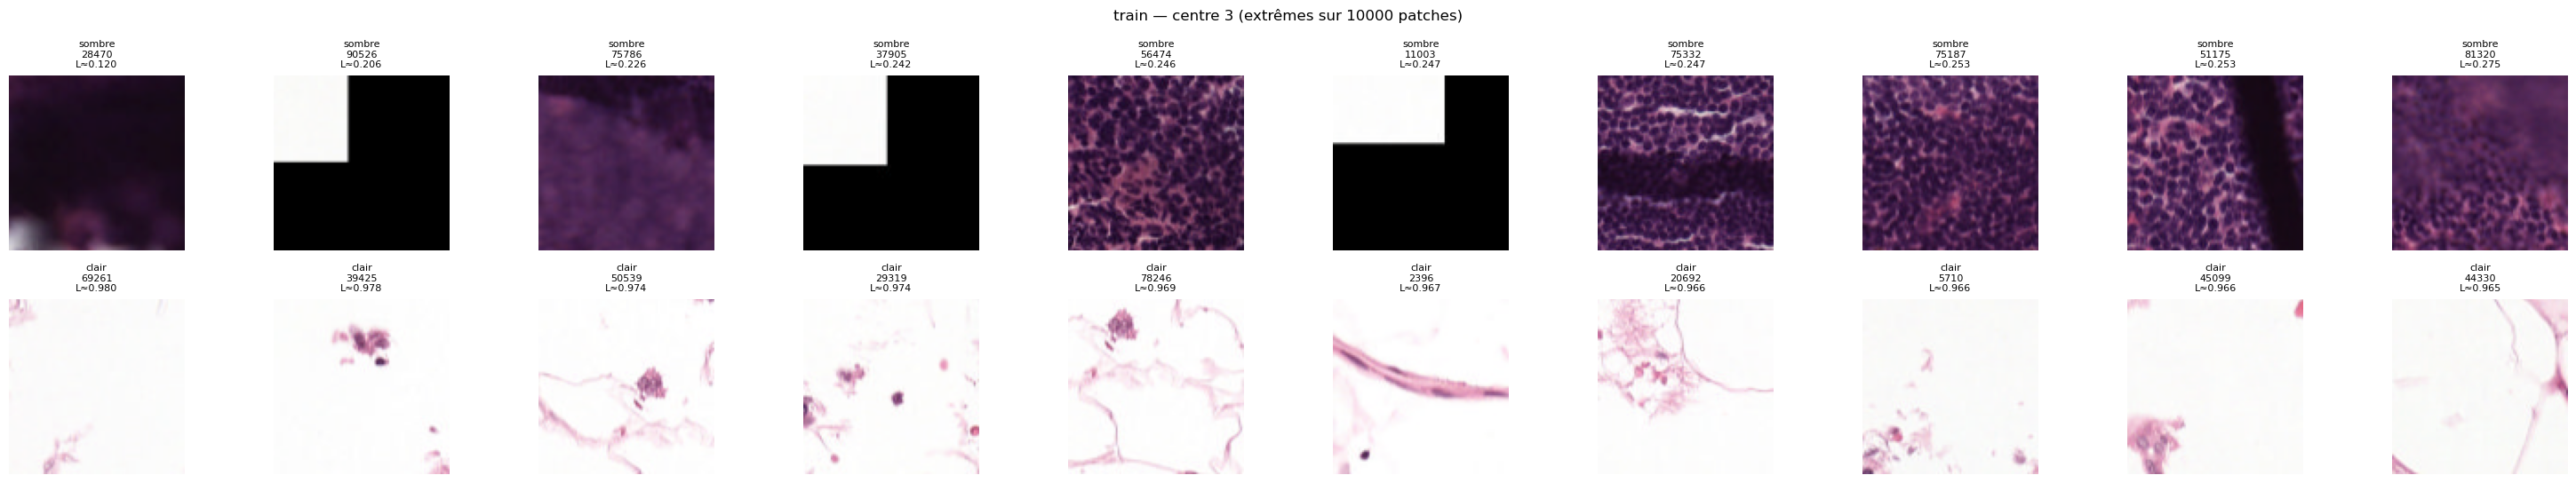

L centre 4:   0%|          | 0/10000 [00:00<?, ?it/s]

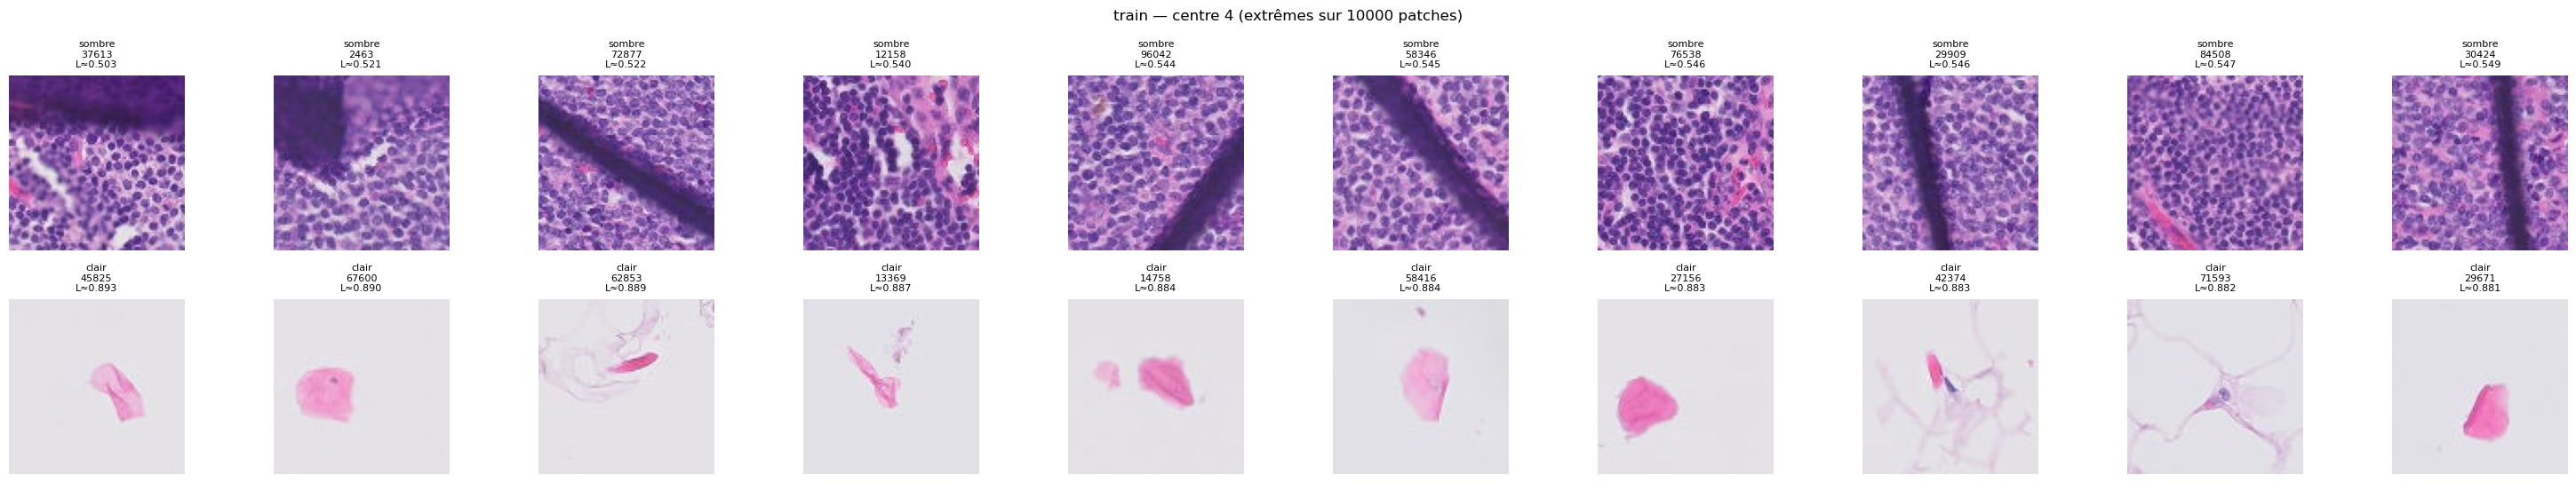

L centre 1:   0%|          | 0/10000 [00:00<?, ?it/s]

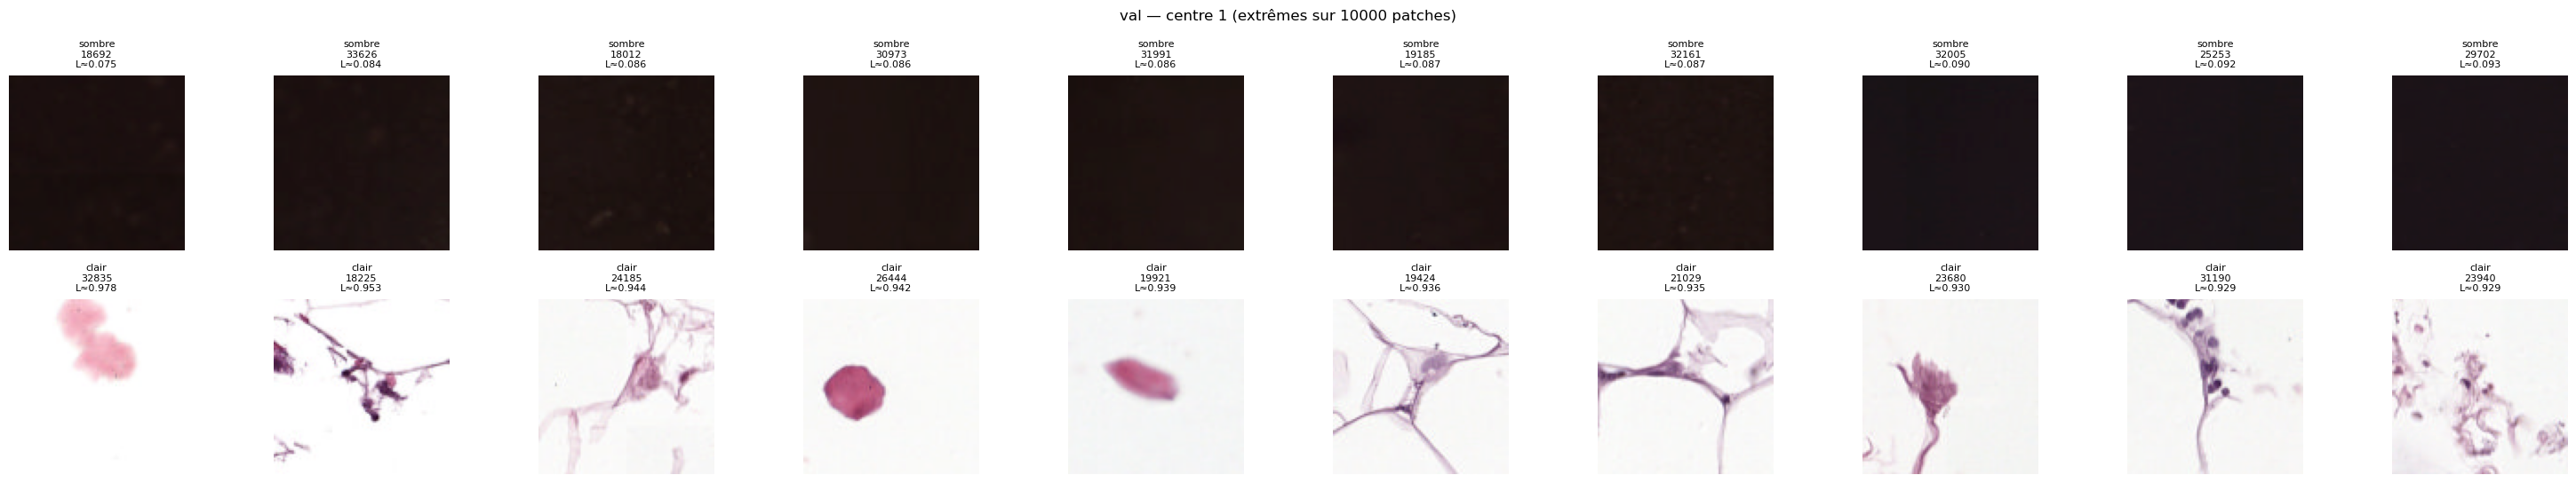

L tout le jeu:   0%|          | 0/10000 [00:00<?, ?it/s]

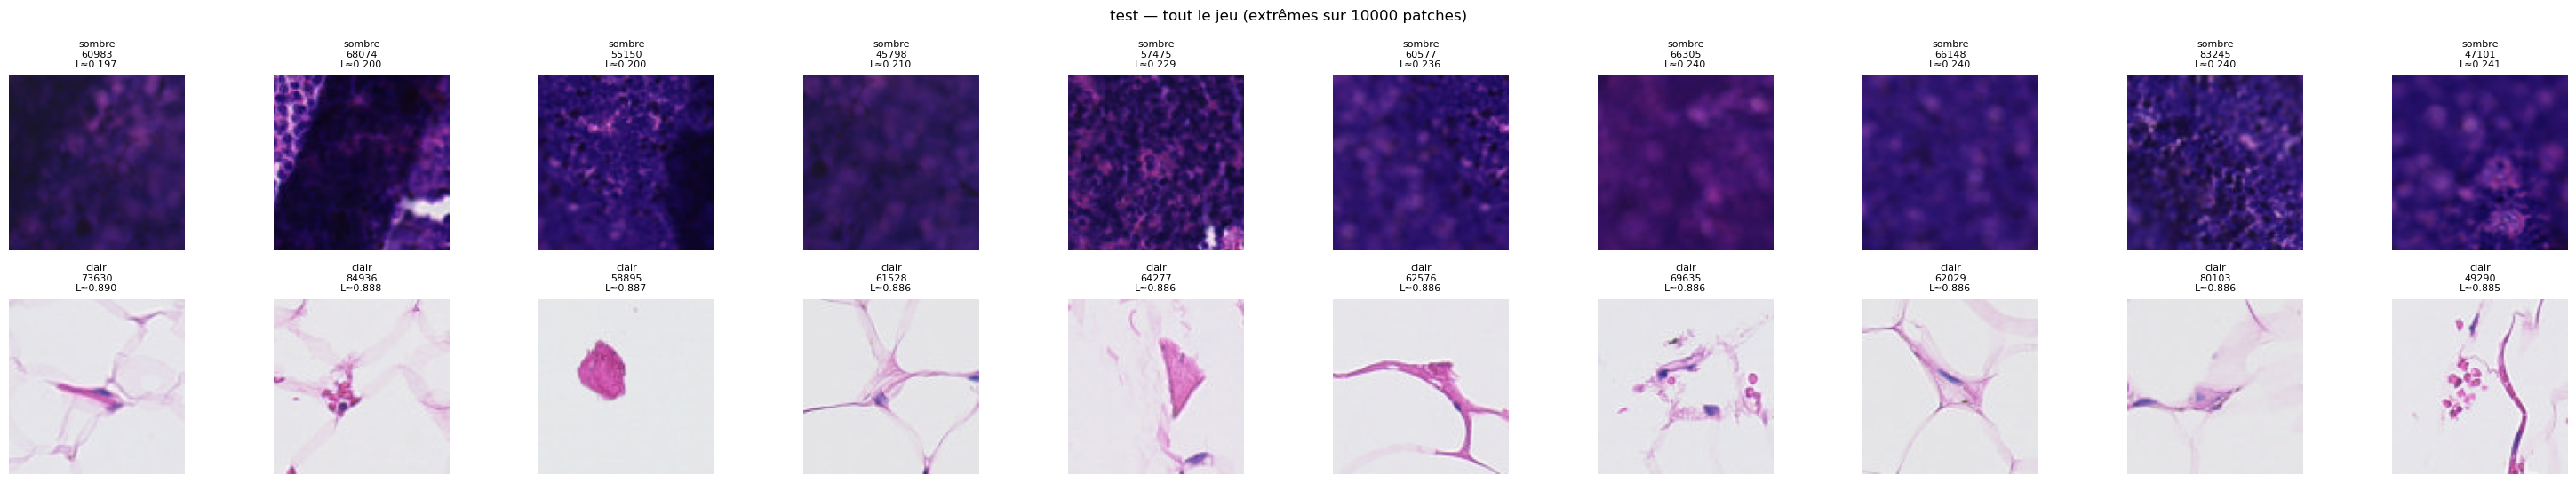

In [ ]:
EXTREME_N = 10
EXTREME_SAMPLE = 10000


def mean_brightness(img: np.ndarray) -> float:
    return float(np.array(img, dtype=np.float64).mean())


def show_extreme_grid(h5_path: str, ids_scores: list, title: str):
    ids_scores = sorted(ids_scores, key=lambda t: t[1])
    low = ids_scores[:EXTREME_N]
    high = ids_scores[-EXTREME_N:][::-1]
    pick = [("sombre", low), ("clair", high)]
    fig, axs = plt.subplots(2, EXTREME_N, figsize=(3 * EXTREME_N, 5.5))
    with h5py.File(h5_path, "r") as f:
        for r, (lab, lst) in enumerate(pick):
            for j, (k, sc) in enumerate(lst):
                ax = axs[r, j]
                vis = tensor_chw_to_display(np.array(f[k]["img"]))
                if vis.ndim == 2:
                    ax.imshow(vis, cmap="gray")
                else:
                    ax.imshow(vis)
                ax.axis("off")
                ax.set_title(f"{lab}\n{k}\nL≈{sc:.3f}", fontsize=8)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


for split_name, path in [("train", TRAIN_IMAGES_PATH), ("val", VAL_IMAGES_PATH), ("test", TEST_IMAGES_PATH)]:
    if not Path(path).is_file():
        continue
    sub_all = df[df["split"] == split_name]
    centers = sorted(sub_all["center"].dropna().unique())

    def run_group(sub: pd.DataFrame, title_suffix: str):
        ids = sub["id"].tolist()
        rng.shuffle(ids)
        ids = ids[:EXTREME_SAMPLE]
        scored = []
        with h5py.File(path, "r") as f:
            for k in tqdm(ids, desc=f"L {title_suffix}", leave=False):
                scored.append((k, mean_brightness(f[k]["img"])))
        show_extreme_grid(path, scored, f"{split_name} — {title_suffix} (extrêmes sur {len(ids)} patches)")

    if len(centers) == 0:
        run_group(sub_all, "tout le jeu")
    else:
        for center in centers:
            run_group(sub_all[sub_all["center"] == center], f"centre {int(center)}")


### 6.5 Comparer le profil « moyenne par canal » de la validation à chaque centre du train

On utilise le tableau `stats_df` de la section 6 (sous-échantillon).  
Pour chaque centre **train**, on calcule la distance **L1** (somme des valeurs absolues des différences) entre son vecteur `mean` et celui du **val**.  
Un nombre **plus petit** = profil de couleur **plus proche** du centre de validation (au sens de ces moyennes simples). Ce n’est qu’un indicateur grossier, mais ça aide à interpréter quel domaine train « ressemble » le plus à la val.


,train_center,L1_vs_val_mean
1,3,0.128085
0,0,0.329966
2,4,0.669802


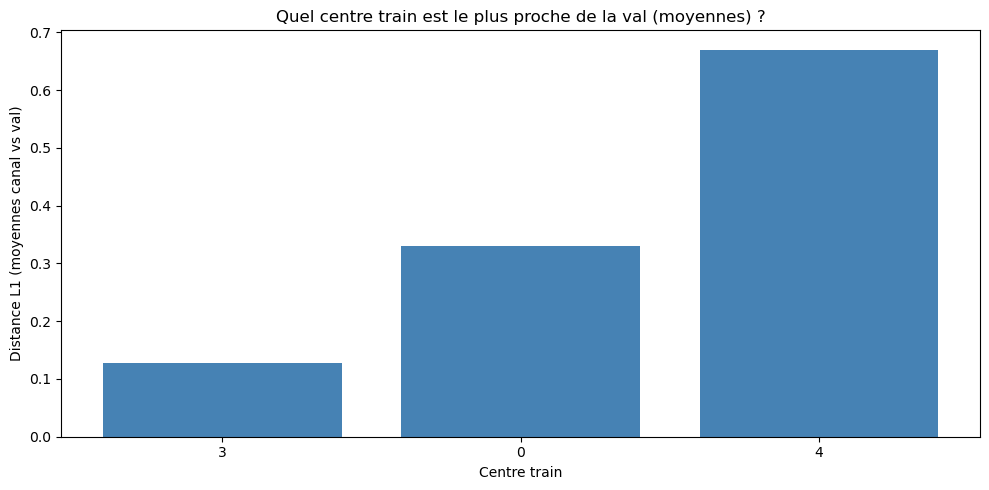

In [ ]:
if "stats_df" in dir() and len(stats_df):
    train_stats = stats_df[stats_df["split"] == "train"].copy()
    val_stats = stats_df[stats_df["split"] == "val"].copy()
    if len(val_stats) and len(train_stats):
        vmean = np.mean([np.array(r["mean"], dtype=np.float64) for _, r in val_stats.iterrows()], axis=0)
        rows_d = []
        for _, r in train_stats.iterrows():
            tmean = np.array(r["mean"], dtype=np.float64)
            d = float(np.sum(np.abs(vmean - tmean)))
            rows_d.append({"train_center": int(r["center"]), "L1_vs_val_mean": d})
        comp = pd.DataFrame(rows_d).sort_values("L1_vs_val_mean")
        display(comp)
        plt.bar(comp["train_center"].astype(str), comp["L1_vs_val_mean"], color="steelblue")
        plt.xlabel("Centre train")
        plt.ylabel("Distance L1 (moyennes canal vs val)")
        plt.title("Quel centre train est le plus proche de la val (moyennes) ?")
        plt.tight_layout()
        plt.show()
    else:
        print("Section 6.5 : besoin d’exactement une ligne val et au moins une ligne train dans stats_df.")
else:
    print("Lancez d’abord la cellule de la section 6 pour créer stats_df.")


## 7. Visualisation « une image par (centre, label) » — train & val

Même esprit que dans `getting_started.ipynb` : grille **centre × label** pour comparer visuellement les **domaines**.

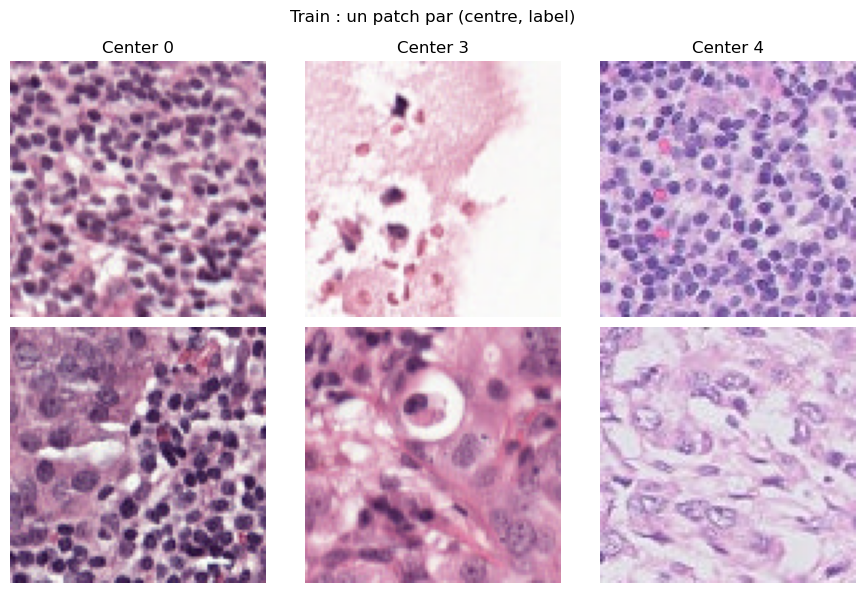

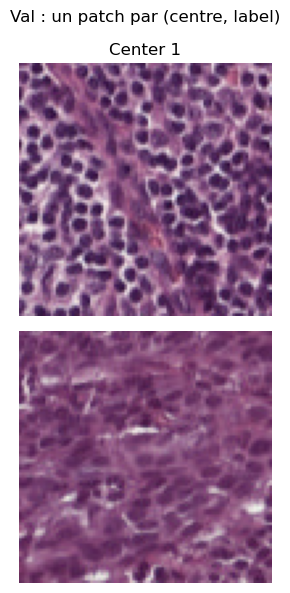

In [ ]:
def pick_one_image_per_center_label(h5_path: str, split_name: str, df_all: pd.DataFrame):
    sub = df_all[(df_all["split"] == split_name) & (~df_all["label"].isna())]
    out = {}
    with h5py.File(h5_path, "r") as f:
        for (center, label), g in sub.groupby(["center", "label"]):
            k = g["id"].iloc[0]
            img = np.array(f[k]["img"])
            out[(int(center), int(label))] = img
    return out


def show_center_label_grid(img_dict: dict, title: str):
    if not img_dict:
        print(f"Rien à afficher pour {title}")
        return
    centers = sorted({c for c, _ in img_dict.keys()})
    labels = sorted({l for _, l in img_dict.keys()})
    fig, axs = plt.subplots(len(labels), len(centers), figsize=(3 * len(centers), 3 * len(labels)))
    if len(labels) == 1:
        axs = np.array([axs])
    if len(centers) == 1:
        axs = axs.reshape(-1, 1)
    for li, label in enumerate(labels):
        for ci, center in enumerate(centers):
            ax = axs[li, ci]
            key = (center, label)
            if key not in img_dict:
                ax.axis("off")
                continue
            vis = tensor_chw_to_display(img_dict[key])
            if vis.ndim == 2:
                ax.imshow(vis, cmap="gray")
            else:
                ax.imshow(vis)
            ax.axis("off")
            if li == 0:
                ax.set_title(f"Center {center}")
            if ci == 0:
                ax.set_ylabel(f"label {label}", rotation=90, size="large")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


if Path(TRAIN_IMAGES_PATH).is_file():
    d_train = pick_one_image_per_center_label(TRAIN_IMAGES_PATH, "train", df)
    show_center_label_grid(d_train, "Train : un patch par (centre, label)")
if Path(VAL_IMAGES_PATH).is_file():
    d_val = pick_one_image_per_center_label(VAL_IMAGES_PATH, "val", df)
    show_center_label_grid(d_val, "Val : un patch par (centre, label)")


## 8. Grille aléatoire — aperçu du domaine test

Le test peut ne pas avoir de `label` : on affiche seulement des patches tirés au hasard.

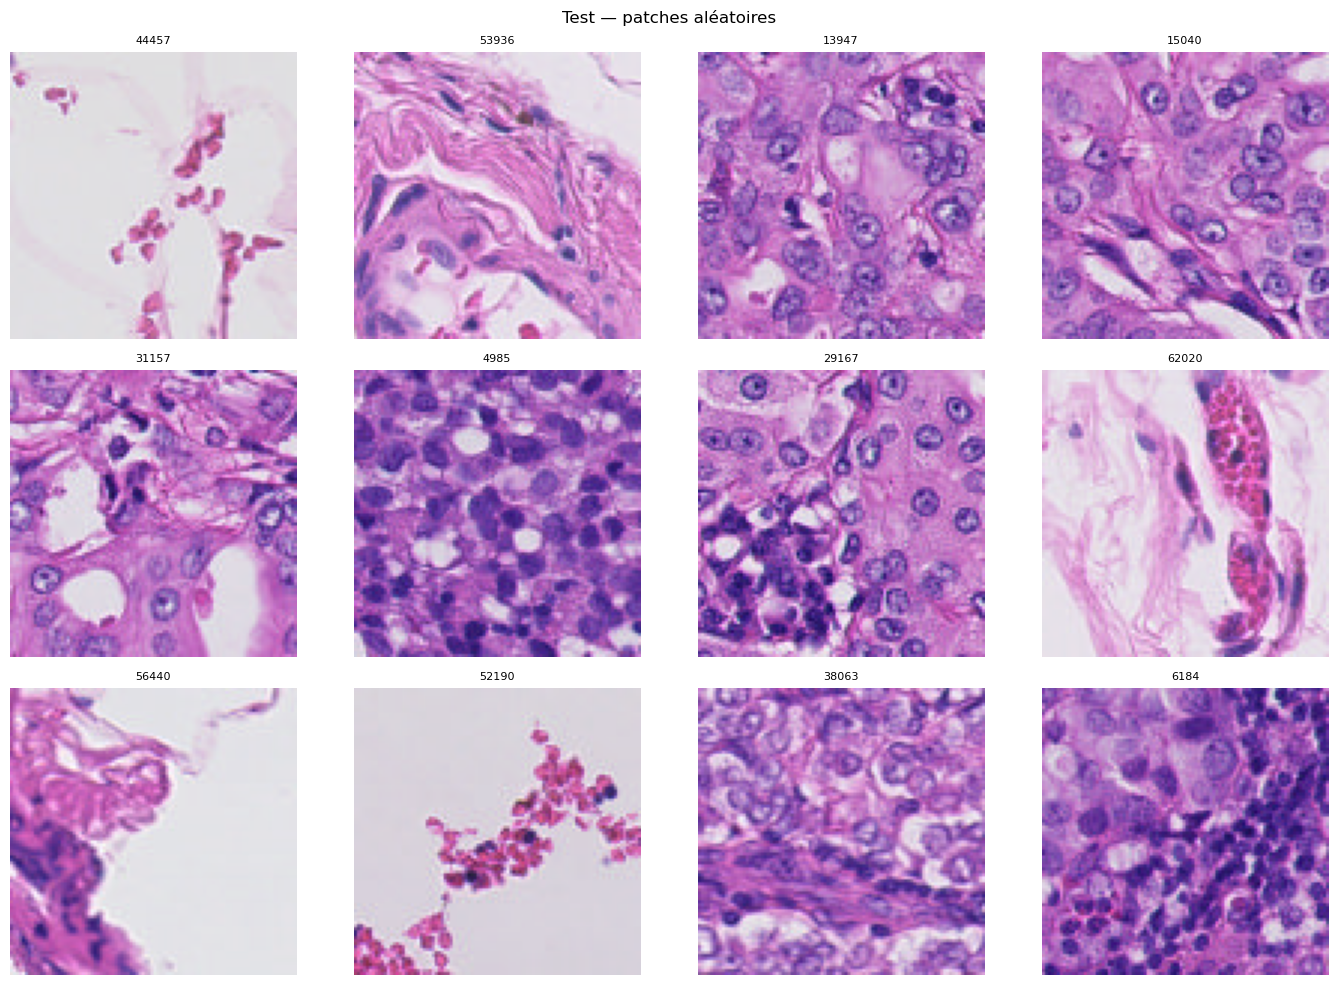

In [ ]:
N_SHOW = 12
if Path(TEST_IMAGES_PATH).is_file():
    test_ids = df[df["split"] == "test"]["id"].tolist()
    rng.shuffle(test_ids)
    pick = test_ids[:N_SHOW]
    fig, axs = plt.subplots(3, 4, figsize=(14, 10))
    with h5py.File(TEST_IMAGES_PATH, "r") as f:
        for ax, k in zip(axs.ravel(), pick):
            vis = tensor_chw_to_display(np.array(f[k]["img"]))
            if vis.ndim == 2:
                ax.imshow(vis, cmap="gray")
            else:
                ax.imshow(vis)
            ax.axis("off")
            ax.set_title(str(k), fontsize=8)
    plt.suptitle("Test — patches aléatoires")
    plt.tight_layout()
    plt.show()
else:
    print("test.h5 absent.")

## 9. Que faire ensuite ? (explications simples)

Tu as des images qui viennent de **plusieurs hôpitaux**. Les couleurs et la luminosité peuvent changer même si la **tâche reste la même** (tumeur ou pas). Ci-dessous : des **pistes de prétraitement** et d’**entraînement**, en langage courant, avec **avantages** et **inconvénients**.

---

### A. Mesurer sans se perdre

| Idée | En clair | Pour | Contre |
|------|-----------|------|--------|
| **Métrique par hôpital (centre)** | Tu calculs la précision (ou score) **séparément** pour chaque centre sur la validation. | Tu vois si le modèle « marche pour tout le monde » ou seulement pour un centre. | Un peu plus de code ; il faut que la val ait un centre identifiable. |
| **Métrique globale** | Une seule moyenne sur toute la validation. | Simple. | Peut **cacher** un centre sur lequel le modèle est mauvais. |

**Conclusion** : garde la métrique **globale** pour suivre l’entraînement, mais regarde **aussi par centre** avant de te féliciter.

---

### B. Prétraitement des images (avant ou pendant l’entraînement)

| Technique | En clair | Avantages | Inconvénients |
|-----------|----------|-----------|----------------|
| **Redimensionner seulement** (comme le baseline) | On met toutes les images à la même taille pour le réseau. | Très simple, rapide. | **Ne corrige pas** les différences de couleur entre hôpitaux. |
| **Normalisation par canal (moyenne / écart-type fixes)** | On soustrait une moyenne et on divise par un écart-type **choisis une fois** (souvent ce du jeu ImageNet si tu utilises un modèle pré-appris). | Standard en vision ; le réseau reçoit des valeurs dans une plage habituelle. | Si tes images **ne ressemblent pas** à ImageNet (histologie, violet…), ce n’est pas toujours optimal. |
| **Normalisation par image (ex. z-score par patch)** | Pour **chaque** image, on centre/réduit chaque canal avec la moyenne et l’écart-type **de cette image**. | Peut **réduire** les différences de luminosité/contraste entre hôpitaux. | Peut **effacer** de vrais signaux faibles ; à tester sur la validation. |
| **Augmentations couleur** (`ColorJitter`, etc.) | Pendant l’entraînement, on modifie un peu aléatoirement couleurs / contraste / luminosité. | Le modèle apprend à ne pas trop dépendre d’**une** teinte précise. | Si c’est trop fort, les images deviennent **irréalistes** ; il faut calibrer. |
| **Normalisation de coloration « métier »** (Macenko, Reinhard, etc.) | Des méthodes pensées pour l’histologie pour rapprocher les **tintes** entre laboratoires. | Peut très bien marcher sur le **décalage entre centres**. | Plus lourd à mettre en place ; parfois plus lent. |

**Conclusion pratique** : commence souvent par **resize + une normalisation cohérente** (ImageNet ou stats calculées sur **ton train**) + **légères** augmentations couleur ; regarde si la val (autre centre) s’améliore. Tu peux ensuite tester **z-score par patch** ou une **coloration** plus poussée.

---

### C. « Batch » et équilibre entre hôpitaux (sans jargon inutile)

Un **batch** = un **petit paquet d’images** traité ensemble à chaque étape d’entraînement (ex. 16 ou 32 images).

| Idée | En clair | Avantages | Inconvénients |
|------|----------|-----------|----------------|
| **Batch aléatoire classique** | On mélange toutes les images du train ; chaque paquet est tiré au hasard. | Simple, implémenté partout. | Si **un hôpital** a **beaucoup plus** d’images, il apparaît **plus souvent** dans chaque paquet → le modèle peut **mieux** apprendre ce style-là. |
| **Paquets plus « équilibrés »** (ex. même nombre de sites par paquet quand c’est possible) | On force à mélanger davantage les hôpitaux dans chaque paquet ou on **ré-échantillonne** pour que chaque site soit représenté régulièrement. | Peut aider si certains centres sont **sous-représentés**. | Un peu plus de réglages ; pas toujours nécessaire si le modèle est déjà robuste. |
| **Pondération** | On donne un **poids plus fort** aux images des centres rares (ou difficiles). | Simple à formuler (on multiplie la « perte » de ces images). | Il faut choisir les poids ; parfois instable si mall configuré. |

**Conclusion** : si un centre a **beaucoup moins** de données, surveille sa performance ; si besoin, teste un **mélange forcé** ou des **poids** plutôt que de ne rien faire.

---

### D. Modèle et entraînement (niveau projet / MVA)

| Idée | En clair | Avantages | Inconvénients |
|------|----------|-----------|----------------|
| **Gros réseau déjà entraîné + petite tête** (ex. DINOv2 + une couche linéaire, comme le baseline) | On **réutilise** des représentations déjà riches ; on n’entraîne qu’une petite partie. | Rapide, souvent **très bon** quand peu de labels ou domaines variés. | Tout le « savoir-faire » est dans le backbone gelé ; parfois un **fine-tuning léger** du backbone aide. |
| **Fine-tuning** | On autorise aussi le gros réseau à **changer un peu**. | Peut gagner en précision **si** la validation le confirme. | Risque de **sur-apprendre** le train (mémoriser les centres vus) ; surveiller la val **autre centre**. |

Les termes **IRM**, **GroupDRO** (littérature « généralisation de domaine ») : ce sont des méthodes mathématiques pour forcer le modèle à marcher sur **plusieurs** types de données à la fois — utiles en recherche ; pour un premier projet, elles sont **optionnelles** si une bonne base + prétraitement + val par centre suffisent.

---

### E. Rappel important sur le test

En compétition, le **test** n’a souvent **pas d’étiquette** publique : tu ne peux pas mesurer ton score dessus directement. La **validation** (souvent un **autre** centre que le train) est donc ton **principal indicateur** pour savoir si ton modèle **généralise** à un nouvel hôpital.

---

**En résumé** : tes graphiques montrent des **différences de statistiques de pixels** → c’est normal en multi-sites ; ça **justifie** d’aller au-delà du simple resize, et de **vérifier** les performances **par centre** et sur la **validation**. Le notebook d’exploration ci-dessus t’aide à quantifier ces écarts avant de coder le pipeline définitif.


# Other :
- use RandomizedSearchCV instead of gridsearchCV
- Resampling the centers that are not expressed enough or add weigths to this class
- bootstrap using df.sample
- metric : F1, AUC, PRAUC, ROC vs PR curve (lire metrics reloaded paper), focal loss?
- adapters inside dinov2 : bottleneck adapter, adaptformer, LoRA, VeRA, aussi prompt tuning ?
- earlystopping
- data augmentation (brightness, color, rotation... pour plus de robustness, segmentation class)

en priorite:
- Stain augmentation (H&E)
- color jitter
- Histogram normalization
- noise/blur
